# Baseline Agent

## Load API tokens for our 3rd party APIs

In [1]:
import os
from dotenv import load_dotenv
_ = load_dotenv()

## Setup a Profile, Prompt and Example Email

In [2]:
profile = {
    "name": "John",
    "full_name": "John Doe",
    "user_profile_background": "Senior software engineer leading a team of 5 developers",
}

In [3]:
prompt_instructions = {
    "triage_rules": {
        "ignore": "Marketing newsletters, spam emails, mass company announcements",
        "notify": "Team member out sick, build system notifications, project status updates",
        "respond": "Direct questions from team members, meeting requests, critical bug reports",
    },
    "agent_instructions": "Use these tools when appropriate to help manage John's tasks efficiently."
}

In [4]:
# Example incoming email
email = {
    "from": "Alice Smith <alice.smith@company.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "body": """
Hi John,

I was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?

Specifically, I'm looking at:
- /auth/refresh
- /auth/validate

Thanks!
Alice""",
}

## Define the first part of the agent - triage.

In [5]:
from pydantic import BaseModel, Field
from typing_extensions import TypedDict, Literal, Annotated
from langchain.chat_models import init_chat_model

In [6]:
llm = init_chat_model("gpt-5-mini")

In [7]:
class Router(BaseModel):
    """Analyze the unread email and route it according to its content."""

    reasoning: str = Field(
        description="Step-by-step reasoning behind the classification."
    )
    classification: Literal["ignore", "respond", "notify"] = Field(
        description="The classification of an email: 'ignore' for irrelevant emails, "
        "'notify' for important information that doesn't need a response, "
        "'respond' for emails that need a reply",
    )

In [8]:
llm_router = llm.with_structured_output(Router)

In [9]:
from prompts import triage_system_prompt, triage_user_prompt

In [10]:
# uncomment to view
#print(triage_system_prompt)
#print(triage_user_prompt)

In [11]:
system_prompt = triage_system_prompt.format(
    full_name=profile["full_name"],
    name=profile["name"],
    examples=None,
    user_profile_background=profile["user_profile_background"],
    triage_no=prompt_instructions["triage_rules"]["ignore"],
    triage_notify=prompt_instructions["triage_rules"]["notify"],
    triage_email=prompt_instructions["triage_rules"]["respond"],
)

In [12]:
user_prompt = triage_user_prompt.format(
    author=email["from"],
    to=email["to"],
    subject=email["subject"],
    email_thread=email["body"],
)

In [13]:
result = llm_router.invoke(
    [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
)

In [14]:
print(result)

reasoning='This is a direct question from a colleague asking whether two API endpoints were intentionally left out of the documentation or if the docs should be updated. It requires John to clarify the intent (or delegate) and potentially trigger a docs update, so it needs a reply. Suggested quick response: acknowledge, confirm whether /auth/refresh and /auth/validate are implemented and intended to be public, and if yes, promise to update the docs or loop in the docs owner with an ETA.' classification='respond'


## Main agent, define tools

In [15]:
from langchain_core.tools import tool

In [16]:
@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write and send an email."""
    # Placeholder response - in real app would send email
    return f"Email sent to {to} with subject '{subject}'"

In [17]:
@tool
def schedule_meeting(
    attendees: list[str], 
    subject: str, 
    duration_minutes: int, 
    preferred_day: str
) -> str:
    """Schedule a calendar meeting."""
    # Placeholder response - in real app would check calendar and schedule
    return f"Meeting '{subject}' scheduled for {preferred_day} with {len(attendees)} attendees"



In [18]:
@tool
def check_calendar_availability(day: str) -> str:
    """Check calendar availability for a given day."""
    # Placeholder response - in real app would check actual calendar
    return f"Available times on {day}: 9:00 AM, 2:00 PM, 4:00 PM"

## Main agent, define prompt

In [19]:
from prompts import agent_system_prompt
def create_prompt(state):
    return [
        {
            "role": "system", 
            "content": agent_system_prompt.format(
                instructions=prompt_instructions["agent_instructions"],
                **profile
                )
        }
    ] + state['messages']

In [20]:
print(agent_system_prompt)


< Role >
You are {full_name}'s executive assistant. You are a top-notch executive assistant who cares about {name} performing as well as possible.
</ Role >

< Tools >
You have access to the following tools to help manage {name}'s communications and schedule:

1. write_email(to, subject, content) - Send emails to specified recipients
2. schedule_meeting(attendees, subject, duration_minutes, preferred_day) - Schedule calendar meetings
3. check_calendar_availability(day) - Check available time slots for a given day
</ Tools >

< Instructions >
{instructions}
</ Instructions >



In [21]:
from langgraph.prebuilt import create_react_agent

In [22]:
tools=[write_email, schedule_meeting, check_calendar_availability]

In [23]:
agent = create_react_agent(
    "gpt-5",
    tools=tools,
    prompt=create_prompt,
)

/var/folders/f9/y_6kq06n4gqdwg1hs_qxfnhm0000gp/T/ipykernel_88755/1391740687.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


In [24]:
response = agent.invoke(
    {"messages": [{
        "role": "user", 
        "content": "what is my availability for tuesday?"
    }]}
)

In [25]:
response["messages"][-1].pretty_print()

================================== Ai Message ==================================

You’re available Tuesday at 9:00 AM, 2:00 PM, and 4:00 PM.


## Create the Overall Agent

In [26]:
from langgraph.graph import add_messages

class State(TypedDict):
    email_input: dict
    messages: Annotated[list, add_messages]

In [27]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from typing import Literal
from IPython.display import Image, display

In [28]:
def triage_router(state: State) -> Command[
    Literal["response_agent", "__end__"]
]:
    author = state['email_input']['author']
    to = state['email_input']['to']
    subject = state['email_input']['subject']
    email_thread = state['email_input']['email_thread']

    system_prompt = triage_system_prompt.format(
        full_name=profile["full_name"],
        name=profile["name"],
        user_profile_background=profile["user_profile_background"],
        triage_no=prompt_instructions["triage_rules"]["ignore"],
        triage_notify=prompt_instructions["triage_rules"]["notify"],
        triage_email=prompt_instructions["triage_rules"]["respond"],
        examples=None
    )
    user_prompt = triage_user_prompt.format(
        author=author, 
        to=to, 
        subject=subject, 
        email_thread=email_thread
    )
    result = llm_router.invoke(
        [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ]
    )
    if result.classification == "respond":
        print("📧 Classification: RESPOND - This email requires a response")
        goto = "response_agent"
        update = {
            "messages": [
                {
                    "role": "user",
                    "content": f"Respond to the email {state['email_input']}",
                }
            ]
        }
    elif result.classification == "ignore":
        print("🚫 Classification: IGNORE - This email can be safely ignored")
        update = None
        goto = END
    elif result.classification == "notify":
        # If real life, this would do something else
        print("🔔 Classification: NOTIFY - This email contains important information")
        update = None
        goto = END
    else:
        raise ValueError(f"Invalid classification: {result.classification}")
    return Command(goto=goto, update=update)

## Put it all together

In [29]:
email_agent = StateGraph(State)
email_agent = email_agent.add_node(triage_router)
email_agent = email_agent.add_node("response_agent", agent)
email_agent = email_agent.add_edge(START, "triage_router")
email_agent = email_agent.compile()

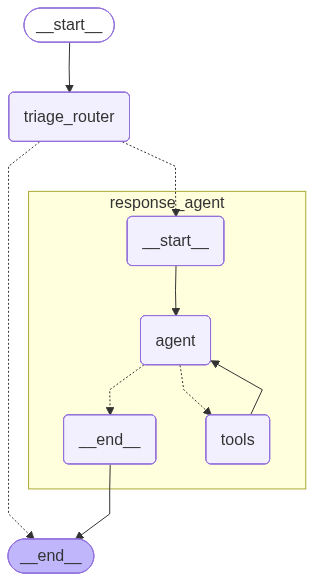

In [30]:
# Show the agent
display(Image(email_agent.get_graph(xray=True).draw_mermaid_png()))

In [31]:
email_input = {
    "author": "Marketing Team <marketing@amazingdeals.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "🔥 EXCLUSIVE OFFER: Limited Time Discount on Developer Tools! 🔥",
    "email_thread": """Dear Valued Developer,

Don't miss out on this INCREDIBLE opportunity! 

🚀 For a LIMITED TIME ONLY, get 80% OFF on our Premium Developer Suite! 

✨ FEATURES:
- Revolutionary AI-powered code completion
- Cloud-based development environment
- 24/7 customer support
- And much more!

💰 Regular Price: $999/month
🎉 YOUR SPECIAL PRICE: Just $199/month!

🕒 Hurry! This offer expires in:
24 HOURS ONLY!

Click here to claim your discount: https://amazingdeals.com/special-offer

Best regards,
Marketing Team
---
To unsubscribe, click here
""",
}

In [32]:
response = email_agent.invoke({"email_input": email_input})

🚫 Classification: IGNORE - This email can be safely ignored


In [33]:
email_input = {
    "author": "Alice Smith <alice.smith@company.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "email_thread": """Hi John,

I was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?

Specifically, I'm looking at:
- /auth/refresh
- /auth/validate

Thanks!
Alice""",
}

In [34]:
response = email_agent.invoke({"email_input": email_input})

📧 Classification: RESPOND - This email requires a response


In [35]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Respond to the email {'author': 'Alice Smith <alice.smith@company.com>', 'to': 'John Doe <john.doe@company.com>', 'subject': 'Quick question about API documentation', 'email_thread': "Hi John,\n\nI was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?\n\nSpecifically, I'm looking at:\n- /auth/refresh\n- /auth/validate\n\nThanks!\nAlice"}
================================== Ai Message ==================================
Tool Calls:
  write_email (call_DXGIVBO8hS3gJYWKWKLlIZEJ)
 Call ID: call_DXGIVBO8hS3gJYWKWKLlIZEJ
  Args:
    to: Alice Smith <alice.smith@company.com>
    subject: Re: Quick question about API documentation
    content: Hi Alice,

Thanks for flagging this. I’ll check with the authentication service team and our docs owner to confirm w

# Semantic Memory Agent

In [36]:
from langgraph.store.memory import InMemoryStore

In [37]:
store = InMemoryStore(index={"embed":"openai:text-embedding-3-small"})

In [38]:
from langmem import create_manage_memory_tool, create_search_memory_tool

In [39]:
manage_memory_tool = create_manage_memory_tool(
    namespace=(
        "email_assistant", 
        "{langgraph_user_id}",
        "collection"
    )
)
search_memory_tool = create_search_memory_tool(
    namespace=(
        "email_assistant",
        "{langgraph_user_id}",
        "collection"
    )
)

In [40]:
print(manage_memory_tool.name)
print(manage_memory_tool.description)

manage_memory
Create, update, or delete a memory to persist across conversations.
Include the MEMORY ID when updating or deleting a MEMORY. Omit when creating a new MEMORY - it will be created for you.
Proactively call this tool when you:

1. Identify a new USER preference.
2. Receive an explicit USER request to remember something or otherwise alter your behavior.
3. Are working and want to record important context.
4. Identify that an existing MEMORY is incorrect or outdated.


In [41]:
manage_memory_tool.args

{'content': {'anyOf': [{'type': 'string'}, {'type': 'null'}],
  'default': None,
  'title': 'Content'},
 'action': {'default': 'create',
  'enum': ['create', 'update', 'delete'],
  'title': 'Action',
  'type': 'string'},
 'id': {'anyOf': [{'format': 'uuid', 'type': 'string'}, {'type': 'null'}],
  'default': None,
  'title': 'Id'}}

In [42]:
print(search_memory_tool.name)
print(search_memory_tool.description)

search_memory
Search your long-term memories for information relevant to your current context.


In [43]:
search_memory_tool.args

{'query': {'title': 'Query', 'type': 'string'},
 'limit': {'default': 10, 'title': 'Limit', 'type': 'integer'},
 'offset': {'default': 0, 'title': 'Offset', 'type': 'integer'},
 'filter': {'anyOf': [{'additionalProperties': True, 'type': 'object'},
   {'type': 'null'}],
  'default': None,
  'title': 'Filter'}}

In [64]:
agent_system_prompt_memory = """
< Role >
You are {full_name}'s executive assistant. You are a top-notch executive assistant who cares about {name} performing as well as possible.
</ Role >

< Tools >
You have access to the following tools to help manage {name}'s communications and schedule:

1. write_email(to, subject, content) - Send emails to specified recipients
2. schedule_meeting(attendees, subject, duration_minutes, preferred_day) - Schedule calendar meetings
3. check_calendar_availability(day) - Check available time slots for a given day
4. manage_memory - Store any relevant information about contacts, actions, discussion, etc. in memory for future reference
5. search_memory - Search for any relevant information that may have been stored in memory
</ Tools >

< Memory protocol >
- ALWAYS call search_memory FIRST, before writing any email or scheduling any meeting,
  to retrieve what you already know about the sender, {name}'s preferences and prior context.
  problematic, be cautious and do NOT proactively schedule with them unless {name} explicitly asks.
- After acting, call manage_memory to store any new relevant fact, commitment, or pending
  request so it can be recalled in future threads.
</ Memory protocol >

< Instructions >
{instructions}
</ Instructions >
"""

In [45]:
def create_prompt(state):
    return [
        {
            "role": "system", 
            "content": agent_system_prompt_memory.format(
                instructions=prompt_instructions["agent_instructions"], 
                **profile
            )
        }
    ] + state['messages']

In [46]:
from langgraph.prebuilt import create_react_agent

In [47]:
tools= [
    write_email, 
    schedule_meeting,
    check_calendar_availability,
    manage_memory_tool,
    search_memory_tool
]
response_agent = create_react_agent(
    "gpt-5.5",
    tools=tools,
    prompt=create_prompt,
    # Use this to ensure the store is passed to the agent 
    store=store
)

config = {"configurable": {"langgraph_user_id": "lance"}}


/var/folders/f9/y_6kq06n4gqdwg1hs_qxfnhm0000gp/T/ipykernel_88755/3050021931.py:8: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  response_agent = create_react_agent(


In [67]:
response = response_agent.invoke(
    {"messages": [{"role": "user", "content": "I like to take nap from 2-2:15 pm"}]},
    config=config
)

In [68]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

I like to take nap from 2-2:15 pm
================================== Ai Message ==================================
Tool Calls:
  manage_memory (call_36Ktqb3JybYq6D93r5ibHq0v)
 Call ID: call_36Ktqb3JybYq6D93r5ibHq0v
  Args:
    action: create
    content: John prefers to take a nap from 2:00–2:15 PM. Avoid scheduling meetings during this time when possible.
================================= Tool Message =================================
Name: manage_memory

created memory 4c004f9e-16ea-4753-ae59-5fc880474ae4
================================== Ai Message ==================================

Got it — I’ll avoid scheduling meetings from 2:00–2:15 PM for your nap whenever possible.


In [69]:
response = response_agent.invoke(
    {"messages": [{"role": "user", "content": "who are jim and pepe?"}]},
    config=config
)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

who are jim and pepe?
================================== Ai Message ==================================
Tool Calls:
  search_memory (call_mxepK37gqb9BEWxuqc72yQKZ)
 Call ID: call_mxepK37gqb9BEWxuqc72yQKZ
  Args:
    query: Jim Pepe who are Jim and Pepe contacts context
    limit: 10
================================= Tool Message =================================
Name: search_memory

[{"namespace":["email_assistant","lance","collection"],"key":"5c859d5d-a0bc-4dfd-9ad6-d6c2799a4174","value":{"content":"Pepe is John's enemy / problematic contact. Be cautious and do not proactively schedule or engage with Pepe unless John explicitly asks."},"created_at":"2026-06-05T03:32:46.982307+00:00","updated_at":"2026-06-05T03:32:46.982317+00:00","score":0.5200467853696739},{"namespace":["email_assistant","lance","collection"],"key":"3d1f6785-579a-4eb8-b626-dfe15f86c85f","value":{"content":"Jim is John's friend."},"create

In [51]:
store.list_namespaces()

[('email_assistant', 'lance', 'collection')]

store.search(('email_assistant', 'lance', 'collection'))

In [70]:
store.search(('email_assistant', 'lance', 'collection'))

[Item(namespace=['email_assistant', 'lance', 'collection'], key='3d1f6785-579a-4eb8-b626-dfe15f86c85f', value={'content': "Jim is John's friend."}, created_at='2026-06-05T03:31:38.219975+00:00', updated_at='2026-06-05T03:31:38.219979+00:00', score=None),
 Item(namespace=['email_assistant', 'lance', 'collection'], key='e6107e7d-64f5-4299-8e6e-b4612a83c801', value={'content': 'Responded to Alice Smith <alice.smith@company.com> re: API documentation for new authentication service. John asked Alice for the docs version/branch and said he would verify whether /auth/refresh and /auth/validate were intentionally omitted or should be added/updated/marked internal.'}, created_at='2026-06-05T03:32:00.793911+00:00', updated_at='2026-06-05T03:32:00.793925+00:00', score=None),
 Item(namespace=['email_assistant', 'lance', 'collection'], key='5c859d5d-a0bc-4dfd-9ad6-d6c2799a4174', value={'content': "Pepe is John's enemy / problematic contact. Be cautious and do not proactively schedule or engage with

In [71]:
store.search(('email_assistant', 'lance', 'collection'), query="nap")

[Item(namespace=['email_assistant', 'lance', 'collection'], key='4c004f9e-16ea-4753-ae59-5fc880474ae4', value={'content': 'John prefers to take a nap from 2:00–2:15 PM. Avoid scheduling meetings during this time when possible.'}, created_at='2026-06-05T03:33:20.842780+00:00', updated_at='2026-06-05T03:33:20.842790+00:00', score=0.2547023784982721),
 Item(namespace=['email_assistant', 'lance', 'collection'], key='5c859d5d-a0bc-4dfd-9ad6-d6c2799a4174', value={'content': "Pepe is John's enemy / problematic contact. Be cautious and do not proactively schedule or engage with Pepe unless John explicitly asks."}, created_at='2026-06-05T03:32:46.982307+00:00', updated_at='2026-06-05T03:32:46.982317+00:00', score=0.13643871758990117),
 Item(namespace=['email_assistant', 'lance', 'collection'], key='3d1f6785-579a-4eb8-b626-dfe15f86c85f', value={'content': "Jim is John's friend."}, created_at='2026-06-05T03:31:38.219975+00:00', updated_at='2026-06-05T03:31:38.219979+00:00', score=0.11383123226268

## Complete semantic memory agent

In [54]:
from langgraph.graph import add_messages

class State(TypedDict):
    email_input: dict
    messages: Annotated[list, add_messages]

In [55]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from typing import Literal
from IPython.display import Image, display

In [56]:
def triage_router(state: State) -> Command[
    Literal["response_agent", "__end__"]
]:
    author = state['email_input']['author']
    to = state['email_input']['to']
    subject = state['email_input']['subject']
    email_thread = state['email_input']['email_thread']

    system_prompt = triage_system_prompt.format(
        full_name=profile["full_name"],
        name=profile["name"],
        user_profile_background=profile["user_profile_background"],
        triage_no=prompt_instructions["triage_rules"]["ignore"],
        triage_notify=prompt_instructions["triage_rules"]["notify"],
        triage_email=prompt_instructions["triage_rules"]["respond"],
        examples=None
    )
    user_prompt = triage_user_prompt.format(
        author=author, 
        to=to, 
        subject=subject, 
        email_thread=email_thread
    )
    result = llm_router.invoke(
        [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ]
    )
    if result.classification == "respond":
        print("📧 Classification: RESPOND - This email requires a response")
        goto = "response_agent"
        update = {
            "messages": [
                {
                    "role": "user",
                    "content": f"Respond to the email {state['email_input']}",
                }
            ]
        }
    elif result.classification == "ignore":
        print("🚫 Classification: IGNORE - This email can be safely ignored")
        update = None
        goto = END
    elif result.classification == "notify":
        # If real life, this would do something else
        print("🔔 Classification: NOTIFY - This email contains important information")
        update = None
        goto = END
    else:
        raise ValueError(f"Invalid classification: {result.classification}")
    return Command(goto=goto, update=update)

In [57]:
email_agent = StateGraph(State)
email_agent = email_agent.add_node(triage_router)
email_agent = email_agent.add_node("response_agent", response_agent)
email_agent = email_agent.add_edge(START, "triage_router")
email_agent = email_agent.compile(store=store)

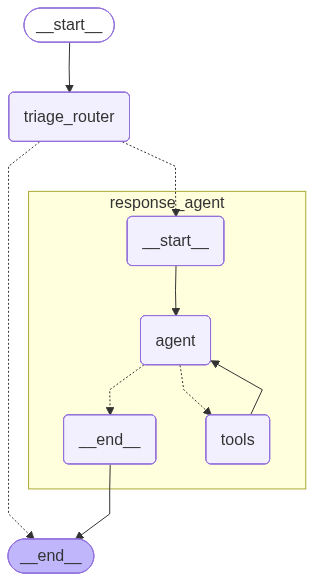

In [58]:
display(Image(email_agent.get_graph(xray=True).draw_mermaid_png()))

In [59]:
email_input = {
    "author": "Alice Smith <alice.smith@company.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "email_thread": """Hi John,

I was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?

Specifically, I'm looking at:
- /auth/refresh
- /auth/validate

Thanks!
Alice""",
}

In [60]:
response = email_agent.invoke(
    {"email_input": email_input},
    config=config
)

📧 Classification: RESPOND - This email requires a response


In [61]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Respond to the email {'author': 'Alice Smith <alice.smith@company.com>', 'to': 'John Doe <john.doe@company.com>', 'subject': 'Quick question about API documentation', 'email_thread': "Hi John,\n\nI was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?\n\nSpecifically, I'm looking at:\n- /auth/refresh\n- /auth/validate\n\nThanks!\nAlice"}
================================== Ai Message ==================================
Tool Calls:
  search_memory (call_nNJqaQkkhDqSBNbN0Cl1ysA1)
 Call ID: call_nNJqaQkkhDqSBNbN0Cl1ysA1
  Args:
    query: Alice Smith API documentation authentication service /auth/refresh /auth/validate John preferences email response
    limit: 10
================================= Tool Message =================================
Name: sea

In [72]:
email_input = {
    "author": "Alice Smith <alice.smith@company.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Follow up",
    "email_thread": """Hi John,

Any update on my previous ask?""",
}

In [ ]:
response = email_agent.invoke({"email_input": email_input}, config=config)

In [ ]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Respond to the email {'author': 'Alice Smith <alice.smith@company.com>', 'to': 'John Doe <john.doe@company.com>', 'subject': 'Follow up', 'email_thread': 'Hi John,\n\nAny update on my previous ask?'}
================================== Ai Message ==================================
Tool Calls:
  search_memory (call_7Z0AvDNsYxNTJpk4zakObgtf)
 Call ID: call_7Z0AvDNsYxNTJpk4zakObgtf
  Args:
    query: Alice Smith previous ask follow up John Doe
    limit: 5
================================= Tool Message =================================
Name: search_memory

[{"namespace":["email_assistant","lance","collection"],"key":"66ee63ed-1895-4a85-bcfa-314124cc7a9f","value":{"content":"John stated that Pepe is his enemy; be cautious and avoid proactively involving Pepe in John's communications or scheduling unless John explicitly requests it."},"created_at":"2026-06-05T03:08:38.677990+00:00","updated_at":"2026-06-05T03:0

In [ ]:
store.search(('email_assistant', 'lance', 'collection'))

[Item(namespace=['email_assistant', 'lance', 'collection'], key='cbd3f258-08a6-4607-983b-982755b1ab0b', value={'content': "Jim is John's friend."}, created_at='2026-06-05T03:04:41.049676+00:00', updated_at='2026-06-05T03:04:41.049679+00:00', score=None),
 Item(namespace=['email_assistant', 'lance', 'collection'], key='66ee63ed-1895-4a85-bcfa-314124cc7a9f', value={'content': "John stated that Pepe is his enemy; be cautious and avoid proactively involving Pepe in John's communications or scheduling unless John explicitly requests it."}, created_at='2026-06-05T03:08:38.677990+00:00', updated_at='2026-06-05T03:08:38.677998+00:00', score=None),
 Item(namespace=['email_assistant', 'lance', 'collection'], key='b4dfd162-b60f-4b72-8b3f-62c0f4e25251', value={'content': 'John prefers to take a nap at 2:00 pm. Avoid scheduling meetings or demanding tasks around 2:00 pm when possible.'}, created_at='2026-06-05T03:09:29.779797+00:00', updated_at='2026-06-05T03:09:29.779805+00:00', score=None),
 Item

In [ ]:
# Friend email
email_jim = {
    "author": "Jim <jim@company.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick sync this week?",
    "email_thread": "Hi John,\n\nWould love to grab 30 minutes to catch up. Could we meet on Tuesday at 2:00 PM?\n\nThanks!\nJim",
}

response = response_agent.invoke(
    {"messages": [{"role": "user", "content": f"Respond to the email {email_jim}"}]},
    config=config
)
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Respond to the email {'author': 'Jim <jim@company.com>', 'to': 'John Doe <john.doe@company.com>', 'subject': 'Quick sync this week?', 'email_thread': 'Hi John,\n\nWould love to grab 30 minutes to catch up. Could we meet on Tuesday at 2:00 PM?\n\nThanks!\nJim'}
================================== Ai Message ==================================
Tool Calls:
  check_calendar_availability (call_9UUHntPAQz8RT9B7JVbLt6Be)
 Call ID: call_9UUHntPAQz8RT9B7JVbLt6Be
  Args:
    day: Tuesday
================================= Tool Message =================================
Name: check_calendar_availability

Available times on Tuesday: 9:00 AM, 2:00 PM, 4:00 PM
================================== Ai Message ==================================
Tool Calls:
  schedule_meeting (call_MmaVq6VYHnj5dOvLfky8m0iT)
 Call ID: call_MmaVq6VYHnj5dOvLfky8m0iT
  Args:
    attendees: ['jim@company.com', 'john.doe@company.com']
    subject: Cat

In [ ]:
# Enemy email
email_pepe = {
    "author": "Pepe <pepe@company.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick sync this week?",
    "email_thread": "Hi John,\n\nWould love to grab 30 minutes to catch up. Could we meet on Tuesday at 2:00 PM?\n\nThanks!\nPepe",
}

response = response_agent.invoke(
    {"messages": [{"role": "user", "content": f"Respond to the email {email_pepe}"}]},
    config=config
)
for m in response["messages"]:
    m.pretty_print()


================================ Human Message =================================

Respond to the email {'author': 'Pepe <pepe@company.com>', 'to': 'John Doe <john.doe@company.com>', 'subject': 'Quick sync this week?', 'email_thread': 'Hi John,\n\nWould love to grab 30 minutes to catch up. Could we meet on Tuesday at 2:00 PM?\n\nThanks!\nPepe'}
================================== Ai Message ==================================
Tool Calls:
  check_calendar_availability (call_9xvkB8ts2MpcFgi6u7qIcuM6)
 Call ID: call_9xvkB8ts2MpcFgi6u7qIcuM6
  Args:
    day: Tuesday
================================= Tool Message =================================
Name: check_calendar_availability

Available times on Tuesday: 9:00 AM, 2:00 PM, 4:00 PM
================================== Ai Message ==================================
Tool Calls:
  schedule_meeting (call_Y6M7rxolmfpQMaeZ2sqMSFqw)
 Call ID: call_Y6M7rxolmfpQMaeZ2sqMSFqw
  Args:
    attendees: ['pepe@company.com', 'john.doe@company.com']
    subject: